# Late Fusion Model:

This notebook presents a **Multimodal Late Fusion Model** developed for the **Rakuten Data Challenge**, targeting a **multiclass classification task** by jointly leveraging **textual and visual information**.

The proposed approach combines:
- **Text modality** processed using a **pretrained BERT-base-uncased** model
- **Image modality** processed using a **pretrained EfficientNet** backbone

Both modalities are trained independently to extract high-level representations, which are then **fused at a late stage** to perform final classification. This **late fusion strategy** allows each modality to specialize while still benefiting from complementary information.

### Key Characteristics of the Approach

- **Framework**: Implemented in **PyTorch**
- **Model Architecture**:
  - BERT-base-uncased for text feature extraction
  - EfficientNet for image feature extraction
  - Late fusion of text and image embeddings
- **Training Strategy**:
  - **Custom training loop** for full control over optimization
  - **Early stopping** to prevent overfitting
  - **Best model checkpointing** based on validation performance
  - **Learning rate scheduler callbacks**
- **Two-Stage Training Procedure**:
  1. **Stage 1**: Train only the classification heads while keeping pretrained backbones frozen
  2. **Stage 2**: Fine-tune:
     - The **last 2 layers of BERT**
     - The **last 50 layers of EfficientNet**
- **Optimization Technique**:
  - **Layer-wise learning rate decay** to stabilize fine-tuning and preserve pretrained knowledge

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms, models
from transformers import BertTokenizer, BertModel, AutoTokenizer
from transformers import AutoModelForSequenceClassification
from torch.utils.data import WeightedRandomSampler
from collections import Counter
from PIL import Image
from tqdm import tqdm
from torch.optim import AdamW
import matplotlib.pyplot as plt
import pandas as pd

import os
import zipfile

2025-11-30 14:30:06.319100: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-30 14:30:06.332881: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764513006.351176    2036 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764513006.356812    2036 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-11-30 14:30:06.374575: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

## Dataset Extraction Utility

This helper function is responsible for **extracting compressed dataset files** before the training process begins. Since the Rakuten dataset is provided in a zipped format, automated extraction ensures reproducibility and simplifies environment setup.

### Function Overview

- Checks whether the target extraction directory exists  
- Creates the directory if it does not exist  
- Extracts all contents of the provided ZIP file into the specified location  

### Purpose in the Pipeline

- Ensures datasets are **ready for preprocessing and loading**
- Avoids manual intervention when setting up experiments
- Makes the notebook portable across different environments (local, cloud, or competition platforms)

This utility is typically executed once during initialization to prepare the raw data for subsequent preprocessing steps.

In [ ]:
def dezip(zip_file_path, extract_to):

    if not os.path.exists(extract_to):
        os.makedirs(extract_to)
    
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)

In [ ]:
dezip(zip_file_path="./images.zip",extract_to="./images")
dezip(zip_file_path="./ds_fusion.zip",extract_to="./ds_fusion")
dezip(zip_file_path="./bert-model.zip",extract_to="./bert-model")
dezip(zip_file_path="./effnet-model.zip",extract_to="./effnet-model")

## Multimodal Dataset Definition

This section defines a custom **PyTorch Dataset** for handling **multimodal inputs**, combining **text and image data** for late fusion training.

### Dataset Structure

Each sample is expected to follow the structure:
```python
{
    "text": "...",   # product description or title
    "image": "...",  # path to product image
    "label": ...     # target class
}

In [3]:
class MultiModalDataset(Dataset):
    def __init__(self, samples, bert_path, image_transform):
        """
        samples:
                 {"text": "...", "image": "...", "label": ...}
        """
        self.samples = samples
        self.tokenizer = AutoTokenizer.from_pretrained(bert_path)
        self.transform = image_transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]

        # TEXT
        encoded = self.tokenizer(
            s["text"],
            padding="max_length",
            truncation=True,
            max_length=128,
            return_tensors="pt"
        )

        input_ids = encoded["input_ids"].squeeze()
        attention_mask = encoded["attention_mask"].squeeze()

        # IMAGE
        img = Image.open(s["image"]).convert("RGB")
        img = self.transform(img)

        label = torch.tensor(s["label"], dtype=torch.long)

        return input_ids, attention_mask, img, label

## EfficientNet Image Classifier

This section defines the **image branch** of the multimodal architecture using a **pretrained EfficientNet-B0** backbone. The model is adapted for the Rakuten classification task and designed to support **two-stage fine-tuning**.

### Model Architecture

- Backbone: **EfficientNet-B0**
- Pretrained weights are loaded from a local checkpoint
- The original classifier head is replaced with a custom classification head:
  - Dropout for regularization
  - Fully connected projection to a 128-dimensional embedding
  - ReLU activation
  - Final linear layer mapping to `num_classes`

This design allows the model to produce both:
- **Class predictions**
- **Intermediate image embeddings** for late fusion

### Pretrained Weight Loading

- Loads a saved EfficientNet state dictionary
- Renames keys to match the current module structure
- Enforces strict weight loading to ensure architectural consistency

### Feature Extraction

The `extract_features` method returns a flattened **image feature vector** after:
- Convolutional feature extraction
- Global average pooling

These features are later used in the **late fusion layer**.

### Fine-Tuning Utilities

To support staged training, the model provides:

- **`freeze_base()`**
  - Freezes all EfficientNet parameters
  - Used during Stage 1 to train only the classification head

- **`unfreeze_top_layers(num_layers=50)`**
  - Unfreezes the last *N* convolutional blocks
  - Used during Stage 2 for controlled fine-tuning
  - Enables better task adaptation while limiting overfitting

This flexible setup integrates seamlessly with the **layer-wise learning rate decay** strategy applied during optimization.

In [4]:
class EfficientNetClassifier(nn.Module):
    def __init__(self, num_classes, effnet_path, dropout=0.5):
        super(EfficientNetClassifier, self).__init__()
        
        # Load pretrained EfficientNet-B0
        self.base_model = models.efficientnet_b0(weights=None)

        self.num_features = self.base_model.classifier[1].in_features
        self.base_model.classifier = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(self.num_features, 128),
            nn.ReLU(),
            nn.Dropout(p=dropout),
            nn.Linear(128, num_classes)
        )

        state_dict = torch.load(effnet_path, map_location="cpu")
        new_state = {}
        for k, v in state_dict.items():
            new_k = k.replace("base_model.", "")
            new_state[new_k] = v

        self.base_model.load_state_dict(new_state, strict=True)
        
    
    def forward(self, x):
        return self.base_model(x)
    
    def extract_features(self, x):
        x = self.base_model.features(x)
        x = self.base_model.avgpool(x)
        x = torch.flatten(x, 1)
        return x
    
    def freeze_base(self):
        """Freeze all base model layers except classifier"""
        for param in self.base_model.parameters():
            param.requires_grad = False
    
    def unfreeze_top_layers(self, num_layers=50):
        """Unfreeze top N layers for fine-tuning"""
        layers = list(self.base_model.features.children())
        for layer in layers[-num_layers:]:
            for param in layer.parameters():
                param.requires_grad = True

## Late Fusion Multimodal Model

This section defines the **Late Fusion architecture** that combines **textual features from BERT** and **visual features from EfficientNet** to perform multimodal classification for the Rakuten Data Challenge.

### Text Branch (BERT)

- Uses a **pretrained BERT-base-uncased** model for text representation
- The classification head provided by Hugging Face is initialized, but only the **base model embeddings** are used
- Extracts the **CLS pooled output** (`pooler_output`) as a fixed-length text feature vector
- All BERT parameters are **frozen during Stage 1 training** to stabilize learning

### Image Branch (EfficientNet)

- Integrates the previously defined **EfficientNetClassifier**
- EfficientNet backbone is initialized with pretrained weights
- All convolutional layers are **frozen in Stage 1**
- Image features are extracted using the `extract_features` method, producing a compact visual embedding

### Late Fusion Strategy

- Text and image embeddings are **concatenated** along the feature dimension
- No early interaction between modalities is introduced
- This design allows each modality to learn independently before fusion, reducing cross-modal interference

### Fusion Classifier Head

The fusion head is a multi-layer perceptron designed to progressively refine multimodal representations:

1. **Feature Combination Layer**
   - Linear projection of concatenated features
   - Batch normalization, ReLU activation, and dropout

2. **Intermediate Abstraction Layer**
   - Further dimensionality reduction with regularization

3. **Compact Representation Layer**
   - Produces a low-dimensional multimodal embedding

4. **Final Classification Layer**
   - Outputs logits for the target number of classes

### Forward Pass Overview

- Extract text features from BERT
- Extract image features from EfficientNet
- Concatenate both feature vectors
- Pass the fused representation through the fusion classifier to obtain final predictions

In [5]:
class LateFusionModel(nn.Module):
    def __init__(self, bert_path, effnet_path, num_classes):
        super(LateFusionModel, self).__init__()

        # BERT
        self.bert = AutoModelForSequenceClassification.from_pretrained(bert_path, num_labels=27)
        self.bert_hidden = self.bert.config.hidden_size

        for p in self.bert.parameters():
            p.requires_grad = False

        # EfficientNet
        self.effnet = EfficientNetClassifier(num_classes=27, effnet_path=effnet_path, dropout=0.5)
        self.effnet.freeze_base()
        # self.effnet.Identity()
        self.effnet_hidden = self.effnet.num_features

        # Fusion Layer
        self.classifier = nn.Sequential(
            # Stage 1: Combine embeddings
            nn.Linear(self.bert_hidden + self.effnet_hidden, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(0.3),
            # Stage 2: Intermediate abstraction
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.2),
            # Stage 3: Compress to compact features
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
            )

    def forward(self, input_ids, attention_mask, image):
        # BERT features (CLS token)
        bert_hidden_states = self.bert.base_model(input_ids=input_ids, attention_mask=attention_mask)
        text_feat = bert_hidden_states.pooler_output

        # ResNet features
        img_feat = self.effnet.extract_features(image)   

        # late fusion: concat
        fused = torch.cat([text_feat, img_feat], dim=1)
        out = self.classifier(fused)

        return out

## Training Configuration and Data Preparation

This section sets up the **training environment**, **data pipelines**, and **model initialization** for the multimodal late fusion approach.

---

### Paths and Global Hyperparameters

- Defines paths to pretrained **BERT** and **EfficientNet** checkpoints
- Configures batch size and **two-stage training schedule**
- Automatically selects **GPU or CPU**
- Enables **mixed precision training** using `torch.cuda.amp.GradScaler` for faster and more memory-efficient training

---

### Image Preprocessing

Two separate image pipelines are used:

#### Validation / Test Transforms
- Resizing to `224 × 224`
- Conversion to tensor
- Normalization using **ImageNet statistics**

These transforms ensure consistent and deterministic evaluation.

#### Training Transforms (Data Augmentation)
A rich augmentation strategy is applied to improve generalization:
- **Geometric augmentations**:
  - Horizontal and vertical flips
  - Random rotation
  - Random resized crops
- **Color augmentations**:
  - Brightness, contrast, saturation, and hue jitter
- **Robustness augmentations**:
  - Random grayscale
  - Gaussian blur
  - Random erasing (cutout) to simulate occlusion

All augmentations are followed by ImageNet normalization to remain compatible with EfficientNet pretraining.

---

### Dataset Loading

- Multimodal samples are loaded from disk using the Hugging Face `datasets` library
- A custom `MultiModalDataset` wraps:
  - Tokenized text inputs for BERT
  - Transformed images for EfficientNet
  - Class labels

Separate datasets are created for **training**, **validation**, and **testing**.

---

### Handling Class Imbalance

To address class imbalance in the Rakuten dataset:

1. **Class frequencies** are computed from training labels  
2. **Inverse-frequency class weights** are calculated  
3. **Per-sample weights** are assigned  
4. A **WeightedRandomSampler** is used to oversample minority classes during training  

This ensures balanced mini-batches without duplicating data on disk.

---

### Loss Function

- Uses **CrossEntropyLoss** with class weights
- Penalizes misclassification of underrepresented classes more strongly

---

### DataLoaders

- Training loader:
  - Uses `WeightedRandomSampler`
  - Shuffling handled implicitly by the sampler
- Validation and test loaders:
  - No shuffling
  - Deterministic evaluation

All loaders use pinned memory and multiple workers for faster data transfer.

---

### Model Initialization

- Instantiates the **LateFusionModel** with:
  - Pretrained BERT for text
  - Pretrained EfficientNet for images
- Moves the model to the selected computation device
- Ready for **Stage 1 training** with frozen backbones

This setup prepares the full multimodal pipeline for efficient and stable training.



In [6]:
bert_path = "./birdy-encoder"
effnet_path = "./effnet-model/best_model_final.pth"

batch_size=16
num_epochs_stage1 = 5
num_epochs_stage2 = 15
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
scaler = torch.cuda.amp.GradScaler()

image_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),  # MUST come first
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

train_transforms = transforms.Compose([
        transforms.Resize((224, 224)),
        
        # Geometric augmentations
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.3),  # Less common for product images
        transforms.RandomRotation(degrees=30),  # Increased from 20
        transforms.RandomResizedCrop(
            224, 
            scale=(0.8, 1.0),  # Zoom in/out
            ratio=(0.9, 1.1)   # Slight aspect ratio changes
        ),
        
        # Color augmentations
        transforms.ColorJitter(
            brightness=0.3,    # Increased from 0.2
            contrast=0.3,      # Increased from 0.2
            saturation=0.3,    # NEW - color intensity changes
            hue=0.1           # NEW - slight color shifts
        ),
        
        # Additional augmentations
        transforms.RandomGrayscale(p=0.1),  # NEW - 10% chance grayscale
        transforms.RandomApply([
            transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0))
        ], p=0.3),  # NEW - 30% chance blur (simulates focus issues)
        
        # Convert to tensor
        transforms.ToTensor(),
        
        # Normalize with ImageNet stats
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        
        # Post-tensor augmentation
        transforms.RandomErasing(
            p=0.25,              # 25% chance
            scale=(0.02, 0.2),   # Erase 2-20% of image
            ratio=(0.3, 3.3),    # Aspect ratio of erased region
            value='random'       # Fill with random noise
        )  # NEW - Cutout/Random Erasing (helps with occlusion)
    ])

from datasets import load_from_disk
samples = load_from_disk("./ds_fusion")

# train_ds = MultiModalDataset(samples["train"], bert_path = bert_path, image_transform=image_transform)
# train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, pin_memory=True)

# 1. Build dataset
train_ds = MultiModalDataset(samples["train"], bert_path, train_transforms)

# 2. Compute class weights
train_labels = [s["label"] for s in samples["train"]]
label_counts = Counter(train_labels)
num_classes = len(label_counts)

total_samples = len(train_labels)
class_weights = {cls: total_samples / (num_classes * count)
                 for cls, count in label_counts.items()}

# 3. Assign per-sample weights
sample_weights = torch.DoubleTensor([class_weights[s] for s in train_labels])

# 4. Build sampler
sampler = WeightedRandomSampler(
    sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# 5. Train loader with sampler
train_loader = DataLoader(
    train_ds,
    batch_size=batch_size,
    sampler=sampler,
    pin_memory=True,
    num_workers=6
)

# 6. Loss function with class weight (optional)
ce_weights = torch.tensor(
    [class_weights[i] for i in range(num_classes)],
    dtype=torch.float
).to(device)

criterion = nn.CrossEntropyLoss(weight=ce_weights)

val_ds = MultiModalDataset(samples["val"], bert_path = bert_path, image_transform=image_transform)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, pin_memory=True, num_workers=6)

test_ds = MultiModalDataset(samples["test"], bert_path = bert_path, image_transform=image_transform)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, pin_memory=True, num_workers=6)

model = LateFusionModel(bert_path=bert_path, effnet_path=effnet_path, num_classes=27)
model = model.to(device)

Using device: cuda


/tmp/ipykernel_2036/475003417.py:9: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/opt/conda/lib/python3.12/site-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 6 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


## Training Callbacks: Early Stopping and Model Checkpointing

This section defines lightweight **training callbacks** used inside the custom training loop to improve convergence, prevent overfitting, and preserve the best-performing model.

---

### Early Stopping

The `EarlyStopping` class monitors **validation loss** and stops training when no meaningful improvement is observed.

**Key parameters:**
- `patience`: Number of consecutive epochs without improvement before stopping
- `min_delta`: Minimum decrease in validation loss required to qualify as an improvement

**Behavior:**
- Tracks the best validation loss seen so far
- Resets the counter when improvement occurs
- Triggers early stopping once patience is exceeded

This mechanism helps:
- Avoid overfitting
- Reduce unnecessary computation
- Stabilize multimodal training where convergence can be noisy

---

### Best Model Saving

The `SaveBestModel` callback handles **automatic checkpointing** of the model.

**Key features:**
- Saves the model whenever performance improves
- Supports:
  - `"min"` mode (e.g. validation loss)
  - `"max"` mode (e.g. accuracy or F1 score)
- Stores only the **best-performing model weights**

**Advantages:**
- Guarantees access to the optimal model even if later epochs degrade
- Works seamlessly with early stopping
- Keeps training logic clean and modular

In [13]:
class EarlyStopping:
    def __init__(self, patience=6, min_delta=0.0):
        """
        patience: how many epochs to wait after last improvement
        min_delta: minimum change to qualify as improvement
        """
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

In [14]:
class SaveBestModel:
    def __init__(self, save_path="best_model.pth", mode="min"):
        """
        mode: "min" for loss, "max" for accuracy
        """
        self.save_path = save_path
        self.best_score = None
        self.mode = mode

    def __call__(self, current_score, model):
        if self.best_score is None:
            self.best_score = current_score
            torch.save(model.state_dict(), self.save_path)
        
        elif (self.mode == "min" and current_score < self.best_score) or \
             (self.mode == "max" and current_score > self.best_score):
            
            self.best_score = current_score
            torch.save(model.state_dict(), self.save_path)


## Two-Stage Training Strategy and Optimization

This section implements the **custom training loop** for the multimodal late fusion model, following a **two-stage fine-tuning strategy** with mixed precision, learning rate scheduling, early stopping, and best-model checkpointing.

---

## Stage 1: Train Fusion Head Only

### Objective
- Learn how to **combine text and image representations**
- Keep both **BERT** and **EfficientNet** backbones frozen
- Reduce the risk of destabilizing pretrained features

### Optimization Setup
- **Optimizer**: AdamW applied only to the fusion classifier parameters
- **Learning rate**: `1e-4`
- **Weight decay**: `0.01`
- **Scheduler**: `ReduceLROnPlateau`
  - Reduces LR when validation loss plateaus
- **Mixed Precision Training (AMP)**:
  - Accelerates training
  - Reduces GPU memory usage

### Training Loop
For each epoch:
- Forward pass through the multimodal model
- Compute weighted cross-entropy loss
- Backpropagate using AMP scaling
- Track average training loss

### Validation Loop
- Computes:
  - Validation loss
  - Validation accuracy
- No gradient computation
- Uses AMP for consistency

### Callbacks
- **Early Stopping**: Stops training if validation loss does not improve
- **Best Model Saving**: Automatically saves the best checkpoint
- **LR Scheduler**: Adjusts learning rate based on validation loss

At the end of Stage 1:
- The last model checkpoint is saved
- Training history (loss and accuracy) is stored for later analysis

---

## Stage 2: Fine-Tuning Top Backbone Layers

### Objective
- Adapt pretrained representations to the Rakuten domain
- Fine-tune **only the most informative layers** while preserving general features

### Unfrozen Layers
- **EfficientNet**: Last 50 convolutional layers
- **BERT**:
  - Last 2 encoder layers
  - Pooler layer

### Layer-Wise Learning Rate Strategy
Different learning rates are assigned based on model sensitivity:
- Fusion classifier: `1e-4`
- EfficientNet: `1e-5`
- BERT: `1e-5`

This **layer-wise learning rate decay** stabilizes fine-tuning and prevents catastrophic forgetting.

### Optimization and Scheduling
- AdamW optimizer with parameter groups
- ReduceLROnPlateau scheduler
- Early stopping re-initialized for Stage 2

### Training and Validation
- Same training and evaluation logic as Stage 1
- Metrics tracked independently for comparison

---

## Model Checkpointing and Metrics Logging

- Final model after Stage 2 is saved to disk
- Training histories for both stages are exported as CSV files
- Enables:
  - Offline analysis
  - Experiment comparison
  - Reproducibility

---

## Training Curves Visualization

The final cells visualize:
- **Training vs. validation loss** (Stage 1)
- **Validation accuracy** over epochs

These plots help diagnose:
- Overfitting
- Underfitting
- Convergence behavior

Stage1 Epoch 1:   0%|          | 0/3221 [00:00<?, ?it/s]/tmp/ipykernel_6007/3132631659.py:31: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():  # AMP context
  0%|          | 0/810 [00:00<?, ?it/s]/tmp/ipykernel_6007/3132631659.py:55: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 810/810 [00:30<00:00, 26.52it/s]


[Stage1] Epoch 1: Train Loss 0.3944, Val Loss 0.5261, Val Acc: 0.8580


100%|██████████| 810/810 [00:30<00:00, 26.50it/s]


[Stage1] Epoch 2: Train Loss 0.2248, Val Loss 0.5085, Val Acc: 0.8593


100%|██████████| 810/810 [00:30<00:00, 26.47it/s]


...

[Stage2] Epoch 5: Train Loss 0.0916, Val Loss 0.5563, Val Acc: 0.8689


100%|██████████| 810/810 [00:30<00:00, 26.46it/s]


[Stage2] Epoch 6: Train Loss 0.0824, Val Loss 0.5559, Val Acc: 0.8730


100%|██████████| 810/810 [00:30<00:00, 26.46it/s]


[Stage2] Epoch 7: Train Loss 0.0766, Val Loss 0.5593, Val Acc: 0.8738
Early stopping in Stage 2
Saved final model to fusion_last_stage2.pth


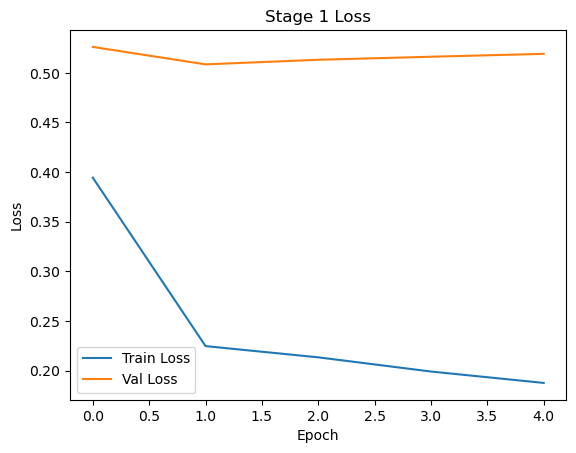

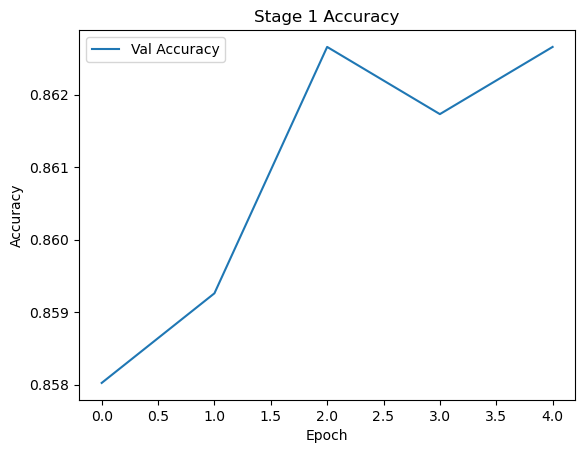

In [15]:
optimizer_stage1 = torch.optim.AdamW(model.classifier.parameters(), lr=1e-4, weight_decay=0.01)
scheduler_stage1 = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_stage1, mode='min', factor=0.5, patience=2)

early_stopping = EarlyStopping(patience=6, min_delta=1e-4)
save_best = SaveBestModel("fusion_best_V4.pth", mode="min")

history_stage1 = {
    "train_loss": [],
    "val_loss": [],
    "val_acc": []
}

# Stage 2
history_stage2 = {
    "train_loss": [],
    "val_loss": [],
    "val_acc": []
}


for epoch in range(num_epochs_stage1):
    model.train()
    train_loss = 0.0
    for input_ids, attention_mask, images, labels in tqdm(train_loader, desc=f"Stage1 Epoch {epoch+1}"):
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        images = images.to(device)
        labels = labels.to(device)

        optimizer_stage1.zero_grad()
        with torch.cuda.amp.autocast():  # AMP context
            logits = model(input_ids, attention_mask, images)
            loss = criterion(logits, labels)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer_stage1)
        scaler.update()

        train_loss += loss.item() * input_ids.size(0)
    
    train_loss /= len(train_loader.dataset)

    # Validation
    model.eval()
    val_loss = 0.0
    correct = 0.0
    total = 0.0
    with torch.no_grad():
        for input_ids, attention_mask, images, labels in tqdm(val_loader):
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            images = images.to(device)
            labels = labels.to(device)

            with torch.cuda.amp.autocast():
                logits = model(input_ids, attention_mask, images)
                loss = criterion(logits, labels)
            val_loss += loss.item() * input_ids.size(0)
                
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_loss /= len(val_loader.dataset)
    val_acc = correct / total
    print(f"[Stage1] Epoch {epoch+1}: Train Loss {train_loss:.4f}, Val Loss {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    # Stage 1
    history_stage1["train_loss"].append(train_loss)
    history_stage1["val_loss"].append(val_loss)
    history_stage1["val_acc"].append(val_acc)

    # Callbacks
    scheduler_stage1.step(val_loss)
    save_best(val_loss, model)
    early_stopping(val_loss)
    if early_stopping.early_stop:
        print("Early stopping in Stage 1")
        break
torch.save(model.state_dict(), "fusion_last_stage1_V4.pth")
print("Saved final model to fusion_last_stage1.pth")

# -------------------------------
# STAGE 2: Fine-tune top layers of backbone
# -------------------------------
model.effnet.unfreeze_top_layers(num_layers=50)

# Unfreeze the last 2 encoder layers
for p in model.bert.bert.encoder.layer[-2:].parameters():
    p.requires_grad = True

# Also, unfreeze the pooler if you want
for p in model.bert.bert.pooler.parameters():
    p.requires_grad = True

# Optimizer with different LRs
optimizer_stage2  = torch.optim.AdamW([
    {"params": model.classifier.parameters(), "lr": 1e-4, "weight_decay": 0.01},
    {"params": model.effnet.parameters(), "lr": 1e-5, "weight_decay": 0.01},
    {"params": model.bert.parameters(), "lr": 1e-5, "weight_decay": 0.01},
])

early_stopping = EarlyStopping(patience=6, min_delta=1e-4)
scheduler_stage2 = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_stage2, mode='min', factor=0.5, patience=2)

for epoch in range(num_epochs_stage2):
    model.train()
    train_loss = 0.0
    for input_ids, attention_mask, images, labels in tqdm(train_loader, desc=f"Stage2 Epoch {epoch+1}"):
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        images = images.to(device)
        labels = labels.to(device)

        optimizer_stage2.zero_grad()
        with torch.cuda.amp.autocast():
            logits = model(input_ids, attention_mask, images)
            loss = criterion(logits, labels)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer_stage2)
        scaler.update()

        train_loss += loss.item() * input_ids.size(0)
    
    train_loss /= len(train_loader.dataset)

    # Validation
    model.eval()
    val_loss = 0.0
    correct = 0.0
    total = 0.0
    with torch.no_grad():
        for input_ids, attention_mask, images, labels in tqdm(val_loader):
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            images = images.to(device)
            labels = labels.to(device)

            with torch.cuda.amp.autocast():
                logits = model(input_ids, attention_mask, images)
                loss = criterion(logits, labels)
            val_loss += loss.item() * input_ids.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_loss /= len(val_loader.dataset)
    val_acc = correct / total
    print(f"[Stage2] Epoch {epoch+1}: Train Loss {train_loss:.4f}, Val Loss {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    history_stage2["train_loss"].append(train_loss)
    history_stage2["val_loss"].append(val_loss)
    history_stage2["val_acc"].append(val_acc)

    # Callbacks
    scheduler_stage2.step(val_loss)
    save_best(val_loss, model)
    early_stopping(val_loss)
    if early_stopping.early_stop:
        print("Early stopping in Stage 2")
        break

# -------------------------------
# Save final model
# -------------------------------
torch.save(model.state_dict(), "fusion_last_stage2_V4.pth")
print("Saved final model to fusion_last_stage2.pth")

# Save Stage 1 metrics as CSV
df_stage1 = pd.DataFrame(history_stage1)
df_stage1.to_csv("history_stage1.csv", index=False)

# Save Stage 2 metrics as CSV
df_stage2 = pd.DataFrame(history_stage2)
df_stage2.to_csv("history_stage2.csv", index=False)


# Example: Stage 1
plt.plot(history_stage1["train_loss"], label="Train Loss")
plt.plot(history_stage1["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Stage 1 Loss")
plt.legend()
plt.show()

plt.plot(history_stage1["val_acc"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Stage 1 Accuracy")
plt.legend()
plt.show()

## Evaluation Utilities: Classification Report and Confusion Matrix

This section defines helper functions used to **evaluate the trained multimodal model** on the validation or test set, providing both **quantitative metrics** and **visual diagnostics**.

---

### Label Mapping Utility

- Loads an `id2label` mapping from disk
- Converts numerical class IDs into **human-readable category names**
- Ensures consistent label interpretation across:
  - Training
  - Evaluation
  - Visualization

This is especially important for the **27-class Rakuten classification task**.

---

### Classification Report

Using `sklearn.metrics.classification_report`, the evaluation includes:
- **Precision**
- **Recall**
- **F1-score**
- **Support** per class

This detailed breakdown helps identify:
- Weak classes
- Class imbalance effects
- Modality-specific confusion patterns

---

### Confusion Matrix Visualization

- Computes a **normalized confusion matrix** (`normalize='true'`)
- Values represent per-class prediction distributions
- Rounded for readability

#### Visualization Details
- Displayed as a **heatmap** using Seaborn
- Large figure size for better readability across 27 classes
- Color-coded intensity highlights frequent confusions
- Axes labeled with semantic class names

In [26]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import json

# ---------------------------------------------------------
# DISPLAY FUNCTION FROM YOU
# ---------------------------------------------------------
def load_id2label(file_path="./id2label"):

    with open(file_path, "r", encoding="utf-8") as f:
        id2_label = json.load(f)
        return id2_label

def id2_label(id2_label, id):
    return id2_label[id]

def display_cm(labels, predicted_classes):

    id2_label = load_id2label()
    ticks = []
    for i in range(27):
        ticks.append(id2_label[str(i)])
    
    class_report = classification_report(labels, predicted_classes)
    print("Classification Report:\n", class_report)

    print("\nConfusion Matrix:")
    cm = confusion_matrix(labels, predicted_classes, normalize='true')

    cm_display = np.round(cm, 2)

    plt.figure(figsize=(20, 10))
    sns.heatmap(cm_display, annot=True, fmt='.2f', cmap='viridis', xticklabels=ticks, yticklabels=ticks)
    plt.title("Confusion Matrix")
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()

## Model Loading and Inference on the Test Set

This section performs **final evaluation** by loading the trained multimodal fusion model and running **inference on the test dataset**.

---

### Device Configuration

- Automatically selects **GPU** if available, otherwise falls back to CPU
- Ensures all tensors and model parameters are placed on the same device
- Uses non-blocking transfers for faster GPU data loading

---

### Model Reconstruction and Weight Loading

- Re-initializes the **LateFusionModel** with:
  - Pretrained BERT for text
  - Pretrained EfficientNet for images
- Loads the **best-performing checkpoint** saved during training
- Switches the model to **evaluation mode**:
  - Disables dropout
  - Ensures deterministic behavior

This guarantees that test results reflect the optimal model state.

---

### Test DataLoader

- Uses the previously defined test dataset
- No shuffling to preserve sample order
- Enables:
  - `pin_memory` for faster host-to-device transfer
  - Multiple workers for parallel data loading

---

### Inference Loop

For each test batch:
- Transfers inputs to the target device
- Performs a forward pass through the multimodal model
- Selects predicted classes using `argmax`
- Collects:
  - Ground-truth labels
  - Model predictions

Gradients are disabled to:
- Reduce memory usage
- Improve inference speed

---

### Output for Evaluation

The collected predictions and labels are later used to:
- Generate a **classification report**
- Plot the **confusion matrix**
- Perform detailed error analysis across all 27 classes

In [ ]:
# ---------------------------------------------------------
# DEVICE
# ---------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

# ---------------------------------------------------------
# LOAD MODEL
# ---------------------------------------------------------
model = LateFusionModel(
    bert_path=bert_path,
    effnet_path=effnet_path,
    num_classes=27
).to(device)

# Load your trained fusion classifier weights if saved separately
# Example:
model.load_state_dict(torch.load("fusion_best_V4.pth"))

model.eval()

# ---------------------------------------------------------
# TEST DATA LOADER (add pin_memory for speed)
# ---------------------------------------------------------
test_loader = DataLoader(
    test_ds, batch_size=8, shuffle=False,
    pin_memory=True, num_workers=4
)

# ---------------------------------------------------------
# INFERENCE ON TEST SET
# ---------------------------------------------------------
all_labels = []
all_preds = []

with torch.no_grad():
    for input_ids, attention_mask, images, labels in tqdm(test_loader, desc="Testing"):

        input_ids = input_ids.to(device, non_blocking=True)
        attention_mask = attention_mask.to(device, non_blocking=True)
        images = images.to(device, non_blocking=True)

        logits = model(input_ids, attention_mask, images)
        preds = logits.argmax(dim=1)

        all_labels.extend(labels.numpy())
        all_preds.extend(preds.cpu().numpy())

Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.68      0.70       620
           1       0.83      0.84      0.83       499
           2       0.78      0.87      0.82       333
           3       0.81      0.97      0.88       165
           4       0.79      0.84      0.81       534
           5       0.97      0.97      0.97       791
           6       0.40      0.82      0.54       153
           7       0.81      0.63      0.71       961
           8       0.70      0.63      0.66       408
           9       0.96      0.91      0.94       981
          10       0.86      0.88      0.87       155
          11       0.73      0.84      0.78       490
          12       0.81      0.82      0.82       633
          13       0.91      0.79      0.85       994
          14       0.90      0.94      0.92       840
          15       0.86      0.96      0.91       160
          16       0.82      0.84      0.83       972
   

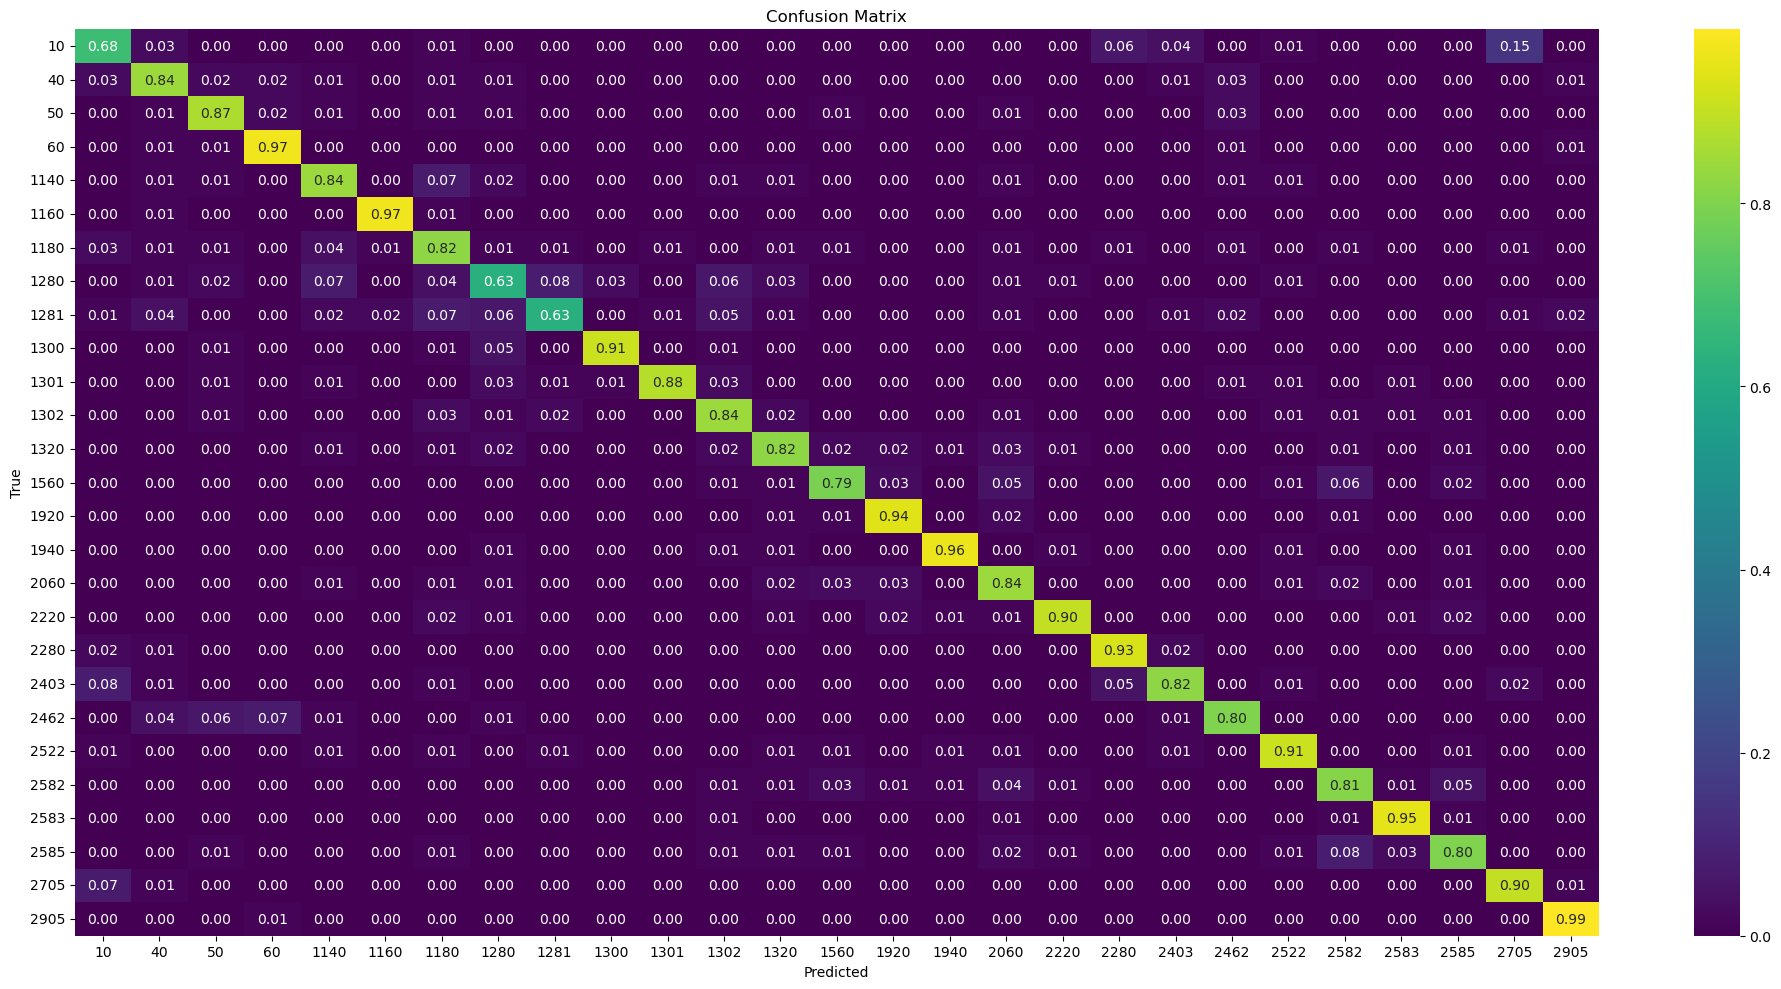

In [27]:
# ---------------------------------------------------------
# DISPLAY RESULTS
# ---------------------------------------------------------
display_cm(all_labels, all_preds)